<a href="https://colab.research.google.com/github/Guillob84/Hand-on-Python/blob/main/Python_Basics_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📌 **Part 2: Topics Covered:**

* Advanced Pythonic Operations.
* Numerical Computing (NumPy).
* Data Manipulation (Pandas).
* Basic Visualization.

🛠️ **Technologies:**

Google Colab (Python 3)

# **Advanced Pythonic Operations**

## 1. List Comprehension with Filtering (Flattening Logs)

Useful when you have a list of lists (like daily logs) and want to flatten them into a single list of events while "removing nulls".

In [1]:
daily_logs = [["login", "click", None], ["click", "buy"], [None, "logout"]]
flat_events = [event for day in daily_logs for event in day if event is not None]
print("Result:", flat_events)

Result: ['login', 'click', 'click', 'buy', 'logout']


## 2. Dictionary Comprehension (ID Mapping)
Transforming raw data into a lookup table for faster access.

In [2]:
users = [("ID001", "Alice"), ("ID002", "Bob"), ("ID003", "Veronica"), ("ID004", "Allen"), ("ID005", "William"), ("ID006", "Bill")]
user_map = {uid: name for uid, name in users}
user_map

{'ID001': 'Alice',
 'ID002': 'Bob',
 'ID003': 'Veronica',
 'ID004': 'Allen',
 'ID005': 'William',
 'ID006': 'Bill'}

In [3]:
print(user_map)

{'ID001': 'Alice', 'ID002': 'Bob', 'ID003': 'Veronica', 'ID004': 'Allen', 'ID005': 'William', 'ID006': 'Bill'}


Transforming to a dataframe using Pandas

In [4]:
import pandas as pd
df_list_user_map = pd.DataFrame(users)
df_list_user_map

,0,1
0,ID001,Alice
1,ID002,Bob
2,ID003,Veronica
3,ID004,Allen
4,ID005,William
5,ID006,Bill


## 3. Using collections.Counter for Frequency Analysis

The most efficient way to get a frequency distribution of categorical data.

In [5]:
from collections import Counter
tags = ["python", "ds", "python", "ml", "ds", "python", "python", "ml", "Dubby", "ds"]
tag_counts = Counter(tags)
print(tag_counts.most_common(2)) # counting the 2 most common (name, count)

[('python', 4), ('ds', 3)]


## 4. collections.defaultdict for Data

Grouping Avoids "KeyError" when grouping data points.

In [6]:
from collections import defaultdict
data = [("North", 10), ("South", 20), ("North", 15)]
grouped_data = defaultdict(list)
for region, value in data:
    grouped_data[region].append(value)
grouped_data

defaultdict(list, {'North': [10, 15], 'South': [20]})

##5. Transposing Data with zip(*data)

A quick "Pythonic" way to flip rows into columns without NumPy.

In [7]:
matrix = [[1, 2], [3, 4], [5, 6]]
columns = list(zip(*matrix))
columns

[(1, 3, 5), (2, 4, 6)]

##6. enumerate with Custom Offsets

Perfect for generating index columns for dataframes that shouldn't start at 0.

In [8]:
names = ["Alice", "Bob", "Charlie", "Margarita", "John", "Stephee", "Sharon", "Michael"]
indexed_names = {i: name for i, name in enumerate(names, start=101)}
indexed_names

{101: 'Alice',
 102: 'Bob',
 103: 'Charlie',
 104: 'Margarita',
 105: 'John',
 106: 'Stephee',
 107: 'Sharon',
 108: 'Michael'}

##7. Multi-Level Sorting with lambda

Sorting a list of dictionaries first by one key, then another (e.g., Score descending, then Name).

In [9]:
students = [{"name": "Alice", "score": 88}, {"name": "Bob", "score": 95},
            {"name": "Charlie", "score": 88}, {"name":"Johan", "score": 75},
            {"name": "Vivian", "score": 82}, {"name":"Mark", "score":95},
            {"name": "Mary Ann", "score": 86}, {"name":"Pedro", "score": 83}]
sorted_students = sorted(students, key=lambda x: (-x['score'], x['name']))
sorted_students

[{'name': 'Bob', 'score': 95},
 {'name': 'Mark', 'score': 95},
 {'name': 'Alice', 'score': 88},
 {'name': 'Charlie', 'score': 88},
 {'name': 'Mary Ann', 'score': 86},
 {'name': 'Pedro', 'score': 83},
 {'name': 'Vivian', 'score': 82},
 {'name': 'Johan', 'score': 75}]

##8. Functional Cleaning with map and filter

Building a lightweight pipeline to clean strings.

In [10]:
raw_data = [" 10.5 ", "20.1", "  error  ", "30.0","35.3",
            "9.0", "!_#$%", "36"]
def is_numeric(s):
    try: return float(s)
    except: return None

cleaned = list(filter(None, map(is_numeric, raw_data)))
cleaned

[10.5, 20.1, 30.0, 35.3, 9.0, 36.0]

##9. Cumulative Aggregation with functools.reduce

Useful for compounding interests or combining complex logic across a series.

In [11]:
from functools import reduce
numbers = [1, 2, 3, 4]
product = reduce(lambda x, y: x * y, numbers) # found 24
product

24

##10. Memory-Efficient Processing with Generators

When dealing with "Big Data" (e.g., 10GB CSVs), generators load one line at a time into RAM.

In [12]:
def read_large_file(file_path):
    with open(file_path) as f:
        for line in f:
            yield line.strip()

data_gen = read_large_file("/content/sample_data/california_housing_train.csv")

print(data_gen)

<generator object read_large_file at 0x7da0170d7100>


##11. Efficient Combinations with itertools.product

Used for Hyperparameter Tuning (Grid Search) without writing nested loops.

In [13]:
from itertools import product
params = {"learning_rate": [0.01, 0.1, 1.0], "epochs": [10, 20]}
combinations = list(product(*params.values()))
combinations

[(0.01, 10), (0.01, 20), (0.1, 10), (0.1, 20), (1.0, 10), (1.0, 20)]

##12. Merging Data Sources with itertools.chain

Iterate over multiple datasets as if they were one, without creating a new large list in memory.

In [14]:
from itertools import chain
data_2023 = [10, 20]
data_2024 = [30, 40]
data_2025 = [50, 60]
for value in chain(data_2023, data_2024,data_2025):
    print(value)

10
20
30
40
50
60


##13. Robust Error Handling (Try-Except-Else)

Using else to execute code only if no error occurred—perfect for API calls.

In [15]:
try:
    result = 10 / 2
except ZeroDivisionError:
    print("Error")
else:
    print(f"Success: {result}")

Success: 5.0


##14. Structuring Data with dataclasses

Replacing dictionaries with classes for better auto-completion and data integrity.

In [16]:
from dataclasses import dataclass

@dataclass
class Observation:
    id: int
    value: float
    label: str

obs = Observation(1, 45.2, "Control")
obs

Observation(id=1, value=45.2, label='Control')

##15. Timing Functions with Decorators

A professional way to profile your data processing functions.

In [17]:
import time

def timer_decorator(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        print(f"Execution time: {time.time() - start:.7f}s") # you can change de decimals on "start"
        return result
    return wrapper

@timer_decorator # the computation that you are interested in
def heavy_computation():
    return [i**2 for i in range(10)]

print(heavy_computation())

heavy_computation()

Execution time: 0.0000029s
[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
Execution time: 0.0000029s


[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]

##16. Path Manipulation with pathlib

The modern way to handle file paths across Windows/Mac/Linux.

In [18]:
from pathlib import Path
data_dir = Path("/content/sample_data")
files = list(data_dir.glob("*.csv")) # Finds all CSVs in the folder
print("This example is from the NoteBook example folder:", files)

This example is from the NoteBook example folder: [PosixPath('/content/sample_data/mnist_train_small.csv'), PosixPath('/content/sample_data/california_housing_test.csv'), PosixPath('/content/sample_data/mnist_test.csv'), PosixPath('/content/sample_data/california_housing_train.csv')]


## 17. Atomic Validation with any() and all()

Quickly check if your data meets quality standards.

In [19]:
scores = [-1, 0, 90, 85, 45, 100]
is_valid = all(s >= 0 for s in scores)
print("It is valid?:", is_valid)

has_outlier = any(s < 50 for s in scores)
print("It has outliers?:", has_outlier)

It is valid?: False
It has outliers?: True


##18. Flexible Arguments with *args and kwargs

Writing functions that can accept any number of data parameters.

In [20]:
def log_metadata(message, **metadata):
    print(f"LOG: {message} | Info: {metadata}")

log_metadata("Process Started", user="Admin", version=1.2)

LOG: Process Started | Info: {'user': 'Admin', 'version': 1.2}


Let's break down the code step by step:

def log_metadata(message, **metadata):

def: This keyword indicates the start of a function definition.
log_metadata: This is the name of the function being defined.
message: This is a regular positional argument. When you call the function, the first value passed will be assigned to message.
**metadata: This is a special syntax in Python. The double asterisks (**) mean that metadata will capture all additional keyword arguments passed to the function as a dictionary. For example, if you call log_metadata('hello', a=1, b=2), then metadata inside the function will be {'a': 1, 'b': 2}.
print(f"LOG: {message} | Info: {metadata}")

print(): This is a built-in Python function that outputs text to the console.
f"LOG: {message} | Info: {metadata}": This is an f-string (formatted string literal). It allows you to embed expressions inside string literals by placing them inside curly braces {}.
{message}: The value of the message argument passed to the function will be inserted here.
{metadata}: The dictionary containing all additional keyword arguments (captured by **metadata) will be inserted here.
log_metadata("Process Started", user="Admin", version=1.2)

This is the function call.
"Process Started": This string is passed as the message argument.
user="Admin": This is a keyword argument. It will be captured by **metadata, so metadata will contain {'user': 'Admin'}.
version=1.2: This is another keyword argument. It will also be captured by **metadata, so metadata will contain {'user': 'Admin', 'version': 1.2}.
When this code runs, the output will be: LOG: Process Started | Info: {'user': 'Admin', 'version': 1.2}

##19. Advanced String Formatting (f-strings)

Formatting data reports with alignment and precision.

In [21]:
metric = 0.89567
name = "Accuracy"
print(f"{name:<10}: {metric:.2%}") # "<10" the quantity of characters; Output: Accuracy  : 89.57%

Accuracy  : 89.57%


##20. Context Managers (with) for Custom Resources

Ensuring database connections or files close correctly even if code crashes.

In [22]:
class DataSession:
    def __enter__(self):
        print("Opening Data Connection...")
        return self
    def __exit__(self, exc_type, exc_val, exc_tb):
        print("Closing Connection Safely.")

with DataSession():
    print("Processing Data...")

Opening Data Connection...
Processing Data...
Closing Connection Safely.


# **Numerical Computing with NumPy**

## 1. Creating Arrays from Raw Data

The fundamental building block. Unlike lists, all elements must be of the same type.

In [23]:
import numpy as np
data = [6.2, 7.1, 5.9, 8.3]
arr = np.array(data)
# Result: array([6.2, 7.1, 5.9, 8.3])
arr

array([6.2, 7.1, 5.9, 8.3])

##2. Multi-dimensional Arrays (Matrices)

Representing structured data like a table or a grid of sensor readings.

In [24]:
matrix = np.array([[1, 2, 3], [4, 5, 6]])
print(f"Shape: {matrix.shape}") # (2, 3) -> 2 rows, 3 columns

#Visualizing the matrix
print(matrix)

Shape: (2, 3)
[[1 2 3]
 [4 5 6]]


##3. Generating Sequences for Time-Series

Creating a range of values, often used for time-steps or coordinate axes.

In [25]:
# Create 10 evenly spaced values between 0 and 1
time_steps = np.linspace(0, 1, 10)
print(time_steps)

[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]


##5. Boolean Indexing (Filtering Data)

The "Pythonic" way to extract specific data points based on conditions.

In [26]:
measurements = np.array([-0.5, 0.5, 1.2, 4.8, 0.2, 6.7, 0.23, 4.5, -1])

# the syntax and interpreting 'outliers' as values > 5.0 OR < 0
outliers = measurements[(measurements > 5.0) | (measurements < 0)]
print("Outliers: ", outliers)

valid_data = measurements[measurements <= 5.0]
print("valid_data: ", valid_data)

Outliers:  [-0.5  6.7 -1. ]
valid_data:  [-0.5   0.5   1.2   4.8   0.2   0.23  4.5  -1.  ]


##7. Reshaping Data for Machine Learning

Changing the structure of data without changing its content (e.g., flattening a 2D image into a 1D vector).

In [27]:
arr = np.arange(12) # 0 to 11
reshaped = arr.reshape(3, 4) # 3 rows, 4 columns
print(reshaped)


[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


##8. Universal Functions (ufuncs)

Applying mathematical functions across an entire array.

In [28]:
values = np.array([1, 2, 3])
log_values = np.log(values)
exp_values = np.exp(values)

print(log_values)
print(exp_values)

[0.         0.69314718 1.09861229]
[ 2.71828183  7.3890561  20.08553692]


## 9. Handling Missing Values (NaN)

In real-world data, some values are missing. NumPy uses nan (Not a Number).

In [29]:
data = np.array([1.0, np.nan, 3.0])
print(f"Mean (ignoring NaN): {np.nanmean(data)}")

Mean (ignoring NaN): 2.0


## 10. Aggregation along Axes

Analyzing data by row or by column (e.g., average score per student vs. average score per subject).

In [30]:
scores = np.array([[80, 90], [70, 85], [95, 100]])
avg_per_col = np.mean(scores, axis=0) # Column averages
avg_per_row = np.mean(scores, axis=1) # Row averages

print(f"Scores: {scores}")
print(f"Column Averages: {avg_per_col}")
print(f"Row Averages: {avg_per_row}")

Scores: [[ 80  90]
 [ 70  85]
 [ 95 100]]
Column Averages: [81.66666667 91.66666667]
Row Averages: [85.  77.5 97.5]


##11. Broadcasting Logic

Performing operations between arrays of different shapes (e.g., subtracting the mean from every element).

In [31]:
data = np.array([10, 20, 30])
normalized = data - np.mean(data)

print(f"Data: {data}")
print(f"Normalized: {normalized}")

Data: [10 20 30]
Normalized: [-10.   0.  10.]


##12. Finding Minimum and Maximum Indices

Useful for identifying the "best" or "worst" performing data point.

In [32]:
yield_rates = np.array([0.85, 0.92, 0.78, 0.95])
best_index = np.argmax(yield_rates) # Returns 3
worst_index = np.argmin(yield_rates) # Returns 1

print(f"Best Index: {best_index}")
print(f"the best value is: {yield_rates[best_index]}")
print(f"Worst Index: {worst_index}")
print(f"the worst value is: {yield_rates[worst_index]}")

Best Index: 3
the best value is: 0.95
Worst Index: 2
the worst value is: 0.78


##13. Generating Random Data for Simulations

Creating synthetic datasets for testing or Monte Carlo simulations.

In [33]:
# 100 samples from a normal distribution (mean=0, std=1)
dist = np.random.normal(0, 1, 100)
sample_1 = dist[0]
sample_2 = dist[1]


print(f"Sample 1: {sample_1}")
print(f"Sample 2: {sample_2}")

Sample 1: 0.1012537242948148
Sample 2: -1.1159917152264813


##14. Matrix Multiplication (Dot Product)

Essential for linear regression and neural network logic.

In [34]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
result = np.dot(A, B)
result

array([[19, 22],
       [43, 50]])

##15. Slicing and Dicing Arrays

Selecting specific sub-sections of your data.

In [35]:
data = np.random.rand(4, 4) #creating a random matrix 4 x 4.
print("data: ", data)
top_left_corner = data[:3, :3] # First 3 rows and 3 columns
print("Top left corner: ", top_left_corner)

data:  [[0.41675311 0.32124406 0.25599178 0.86934106]
 [0.61455096 0.91472435 0.72981148 0.42584982]
 [0.76039921 0.87874825 0.31524351 0.90076165]
 [0.32931732 0.61793726 0.15240474 0.32288325]]
Top left corner:  [[0.41675311 0.32124406 0.25599178]
 [0.61455096 0.91472435 0.72981148]
 [0.76039921 0.87874825 0.31524351]]


## 16. Sorting and Percentiles

Analyzing the distribution of your data.

In [36]:
prices = np.array([100, 200, 150, 300, 250])
p75 = np.percentile(prices, 75) # The value below which 75% of data falls
p75

np.float64(250.0)

## 17. Logical Operations with np.where

Applying "If-Else" logic across an entire dataset.

In [37]:
ph_levels = np.array([6.5, 7.2, 8.1, 5.5])
status = np.where(ph_levels > 7.0, "Alkaline", "Acidic")

print(ph_levels)
print(status)

[6.5 7.2 8.1 5.5]
['Acidic' 'Alkaline' 'Alkaline' 'Acidic']


## 18. Stacking and Concatenation

Combining multiple datasets into one.

In [38]:
week1 = np.array([10, 20])
week2 = np.array([30, 40])
full_month = np.concatenate([week1, week2])
full_month

array([10, 20, 30, 40])

## 19. Unique Values and Counts

Finding the variety in categorical data.

In [39]:
species = np.array(['A', 'B', 'A', 'C', 'B', 'A', 'A', 'C', 'B', 'A'])
unique, counts = np.unique(species, return_counts=True)
# Result: {'A': 3, 'B': 2, 'C': 1}
print(unique, counts)

['A' 'B' 'C'] [5 3 2]


## 20. Memory Management: Views vs. Copies

Understanding how to avoid accidental data modification.

In [40]:
original = np.array([1, 2, 3])
view = original[0:2] # Modification to 'view' changes 'original'
copy = original[0:2].copy() # Modification to 'copy' stays local

print(f"Original: {original}")
print(f"View: {view}")

Original: [1 2 3]
View: [1 2]


# **Data Manipulation with Pandas**

To begin, we always import the library using the standard alias:

In [41]:
import pandas as pd
import numpy as np

## 1. Creating a DataFrame from Scratch

The most common way to start is by converting a dictionary into a DataFrame.

In [42]:
data = {
    'Product': ['Laptop', 'Mouse', 'Monitor', 'Keyboard'],
    'Price': [1200, 25, 300, 75],
    'Stock': [15, 100, 45, 30]
}
df_S = pd.DataFrame(data)
print(df_S)

    Product  Price  Stock
0    Laptop   1200     15
1     Mouse     25    100
2   Monitor    300     45
3  Keyboard     75     30


## 2. Reading External Data

While you can create data, you will mostly load it. (Common formats include CSV, Excel, or JSON).

In [43]:
df_1 = pd.read_csv('/content/sample_data/california_housing_train.csv')
# For now, we will use our 'df' from above.
df_1.head(3) # View the first 3 rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0


## 3. Inspecting Metadata

Before analyzing, you must understand the structure of the data.

In [44]:
df_1.info() # Shows data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


## 4. Descriptive Statistics

Quickly summarize the numerical distribution of your dataset.

In [45]:
df_1.describe() # Generates mean, std, min, max, etc.

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 5. Selecting Columns

Accessing specific features of your data.

In [46]:
Median_house_value = df_1['median_house_value']
# Or multiple columns
Subset_rooms_bedrooms = df_1[['total_rooms', 'total_bedrooms']]

In [47]:
Median_house_value

,median_house_value
0,66900.0
1,80100.0
2,85700.0
3,73400.0
4,65500.0
...,...
16995,111400.0
16996,79000.0
16997,103600.0
16998,85800.0


In [48]:
Subset_rooms_bedrooms

,total_rooms,total_bedrooms
0,5612.0,1283.0
1,7650.0,1901.0
2,720.0,174.0
3,1501.0,337.0
4,1454.0,326.0
...,...,...
16995,2217.0,394.0
16996,2349.0,528.0
16997,2677.0,531.0
16998,2672.0,552.0


## 6. Filtering Data with Boolean Indexing

Finding rows that meet specific criteria.

In [49]:
# Products more expensive than $207.300 USD
expensive_houses = df_1[df_1['median_house_value'] > 207300]
expensive_houses

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
172,-116.26,33.65,3.0,7437.0,1222.0,574.0,302.0,10.2948,382400.0
187,-116.33,33.72,11.0,12327.0,2000.0,2450.0,1139.0,7.4382,353100.0
193,-116.37,33.69,7.0,8806.0,1542.0,858.0,448.0,7.8005,318100.0
199,-116.38,33.71,17.0,12509.0,2460.0,2737.0,1423.0,4.5556,258100.0
203,-116.39,33.69,10.0,11659.0,2007.0,2186.0,1083.0,6.9833,238800.0
...,...,...,...,...,...,...,...,...,...
16802,-123.17,39.18,14.0,2240.0,327.0,1030.0,308.0,5.9585,214900.0
16854,-123.49,38.70,9.0,5409.0,1019.0,594.0,327.0,3.3125,295400.0
16865,-123.70,39.32,18.0,1652.0,352.0,711.0,292.0,3.1071,213200.0
16879,-123.81,39.34,17.0,1981.0,371.0,773.0,325.0,3.1563,277000.0


##7. Using .iloc for Positional Indexing

Selecting data based on its integer location (Row 1, Column 2).

In [50]:
# Get the value in the second row, third column
val = df_1.iloc[1, 2]
print(val)

19.0


## 8. Using .loc for Label Indexing

Selecting data based on the names of the index and columns.

In [51]:
# Get all rows for the 'population' column
population = df_1.loc[:, 'population']
population

,population
0,1015.0
1,1129.0
2,333.0
3,515.0
4,624.0
...,...
16995,907.0
16996,1194.0
16997,1244.0
16998,1298.0


## 9. Adding New Calculated Columns

Deriving new information from existing data.

In [52]:
df_1['total_rooms_and_bedrooms'] = df_1['total_rooms'] + df_1['total_bedrooms']

In [53]:
rooms = df_1['total_rooms_and_bedrooms']
rooms

,total_rooms_and_bedrooms
0,6895.0
1,9551.0
2,894.0
3,1838.0
4,1780.0
...,...
16995,2611.0
16996,2877.0
16997,3208.0
16998,3224.0


In [54]:
df_1

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,total_rooms_and_bedrooms
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,6895.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,9551.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,894.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,1838.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,1780.0
...,...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0,2611.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0,2877.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0,3208.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0,3224.0


## 10. Handling Missing Values (Detection)

Identifying where data is missing is crucial for cleaning.

In [55]:
df_1.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
total_rooms_and_bedrooms,0


## 11. Handling Missing Values (Filling)

Instead of deleting data, you can fill it with a placeholder or a mean.

In [56]:
# It is not the case, but if you need this is the general code:
# df['Column'] = df['Column'].fillna(0)

## 12. Dropping Rows or Columns

Removing unnecessary data.

In [57]:
df_cleaned = df_1.drop(columns=['total_rooms_and_bedrooms'])
df_cleaned #note that the original df_1 stills with the column 'total_rooms_and_bedrooms'

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


## 13. Sorting Data

Ordering your DataFrame by specific values.

In [58]:
df_sorted = df_S.sort_values(by='Price', ascending=False)
df_sorted

,Product,Price,Stock
0,Laptop,1200,15
2,Monitor,300,45
3,Keyboard,75,30
1,Mouse,25,100


## 14. Value Counts

Useful for categorical data to see the frequency of items.

In [59]:
df_S['Product'].value_counts()

,count
Product,
Laptop,1
Mouse,1
Monitor,1
Keyboard,1


## 15. GroupBy: The "Split-Apply-Combine" Pattern

Aggregating data based on a category.

In [60]:
# Example: Average price per product category (if we had a category column)
df_1.groupby('housing_median_age')['median_income'].mean()

,median_income
housing_median_age,
1.0,4.756800
2.0,5.074237
3.0,5.572013
4.0,5.196055
5.0,4.732460
6.0,4.463901
7.0,4.368441
8.0,4.412988
9.0,4.357513


## 16. Renaming Columns

Making the dataset more readable.

In [61]:
df = df_S.rename(columns={'Price': 'Unit_Price', 'Stock': 'Quantity'})
df

,Product,Unit_Price,Quantity
0,Laptop,1200,15
1,Mouse,25,100
2,Monitor,300,45
3,Keyboard,75,30


In [62]:
df_S

,Product,Price,Stock
0,Laptop,1200,15
1,Mouse,25,100
2,Monitor,300,45
3,Keyboard,75,30


## 17. Applying Custom Functions

Using .apply() to transform data with a function or lambda.

In [63]:
df['Price_Category'] = df['Unit_Price'].apply(lambda x: 'High' if x > 200 else 'Low')
df

,Product,Unit_Price,Quantity,Price_Category
0,Laptop,1200,15,High
1,Mouse,25,100,Low
2,Monitor,300,45,High
3,Keyboard,75,30,Low


## 18. Merging DataFrames (Joins)

Combining two different DataFrames on a common key.

In [64]:
other_data = pd.DataFrame({'Product': ['Laptop', 'Mouse'], 'Brand': ['TechCo', 'Logi']})
merged_df = pd.merge(df, other_data, on='Product', how='left')

In [65]:
merged_df

,Product,Unit_Price,Quantity,Price_Category,Brand
0,Laptop,1200,15,High,TechCo
1,Mouse,25,100,Low,Logi
2,Monitor,300,45,High,NaN
3,Keyboard,75,30,Low,NaN


## 19. Pivot Tables

Summarizing data in a spreadsheet-style table.

In [66]:
pivot = df.pivot_table(values='Unit_Price', index='Product', aggfunc='mean')

In [67]:
pivot

,Unit_Price
Product,
Keyboard,75.0
Laptop,1200.0
Monitor,300.0
Mouse,25.0


## 20. Exporting Data

Saving your cleaned work back to a file.

In [68]:
df.to_csv('cleaned_data.csv', index=False)

#

# **Basic Visualization**

**Data Visualization with Matplotlib and Seaborn**

Before writing the exercises, ensure your notebook initializes the libraries correctly in its first visualization cell:

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean default style for GitHub presentations
sns.set_theme(style="whitegrid")

## 1.Basic Line Plot (Introduction to Axes Geometry)

Learn to initialize a plot container without using outdated structures like .figure(), configuring functional math representations.

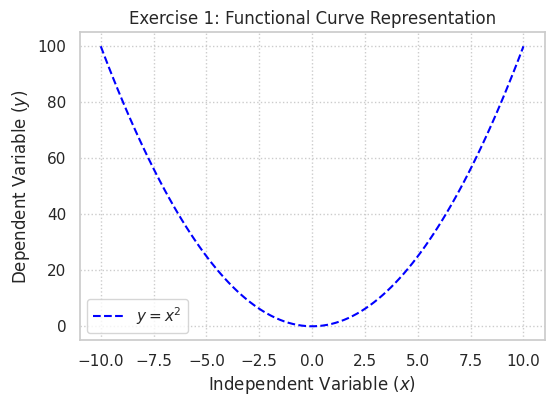

In [70]:
# Generate continuous mathematical values to visualize the curve
x = np.linspace(-10, 10, 100)
y = x**2

# Object-oriented plotting layout setup
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y, label='$y = x^2$', color='blue', linestyle='--')

ax.set_title('Exercise 1: Functional Curve Representation')
ax.set_xlabel('Independent Variable ($x$)')
ax.set_ylabel('Dependent Variable ($y$)')
ax.legend()
ax.grid(True, linestyle=':')

# Saving the figure automatically for repository assets
plt.savefig('exercise_1_line_plot.png', bbox_inches='tight')

## 2. Simple Scatter Plot (Anscombe's Quartet - Series I)

Map relationship trends between two numeric metrics from the Anscombe JSON file.

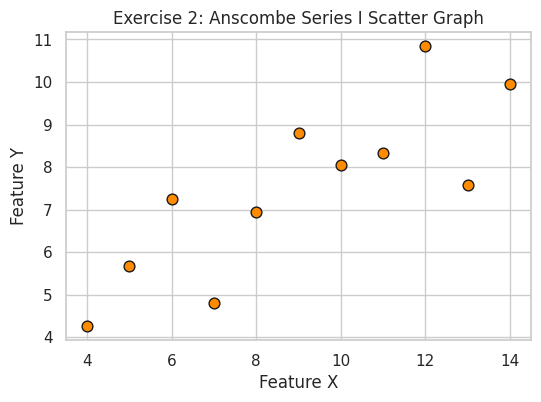

In [71]:
# Naming the file as df
df_anscombe = pd.read_json("/content/sample_data/anscombe.json")
series_i = df_anscombe[df_anscombe['Series'] == 'I']
# Defining Axes and colors
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(series_i['X'], series_i['Y'], color='darkorange', edgecolors='k', s=60)
# Visualizing the scatter plot
ax.set_title('Exercise 2: Anscombe Series I Scatter Graph')
ax.set_xlabel('Feature X')
ax.set_ylabel('Feature Y')
plt.savefig('exercise_2_scatter.png', bbox_inches='tight')

## 3.Scatter Plot with a Linear Trend (Seaborn Regression)

Superimpose a statistical linear regression trend over continuous variables.

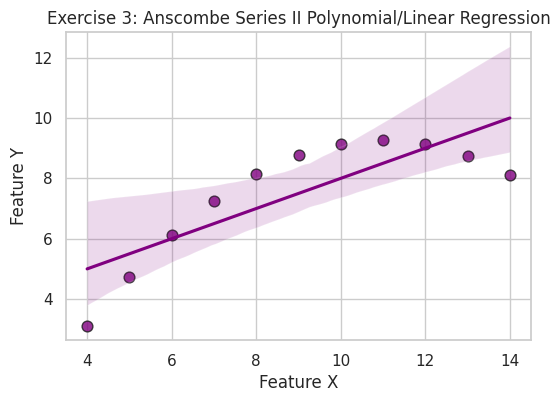

In [72]:
#Naming the df series
series_ii = df_anscombe[df_anscombe['Series'] == 'II']

#Defining axes and colors
fig, ax = plt.subplots(figsize=(6, 4))
sns.regplot(data=series_ii, x='X', y='Y', ax=ax, color='purple',
            scatter_kws={'s': 60, 'edgecolor': 'k'})

#visualizing the scatter plot with a statistical linear regression trend
ax.set_title('Exercise 3: Anscombe Series II Polynomial/Linear Regression')
ax.set_xlabel('Feature X')
ax.set_ylabel('Feature Y')
plt.savefig('exercise_3_regplot.png', bbox_inches='tight')

## 4. Multi-Panel Visualizations ($2 \times 2$ Grid)

Recreate Anscombe's Quartet to see why visualizing data is mandatory before executing statistical summaries.

In [76]:
# Visualizing the df_anscombe data to understand the panels
df_anscombe

,Series,X,Y
0,I,10,8.04
1,I,8,6.95
2,I,13,7.58
3,I,9,8.81
4,I,11,8.33
5,I,14,9.96
6,I,6,7.24
7,I,4,4.26
8,I,12,10.84
9,I,7,4.81


we are going to separate the series to visualize how each series are distributed.

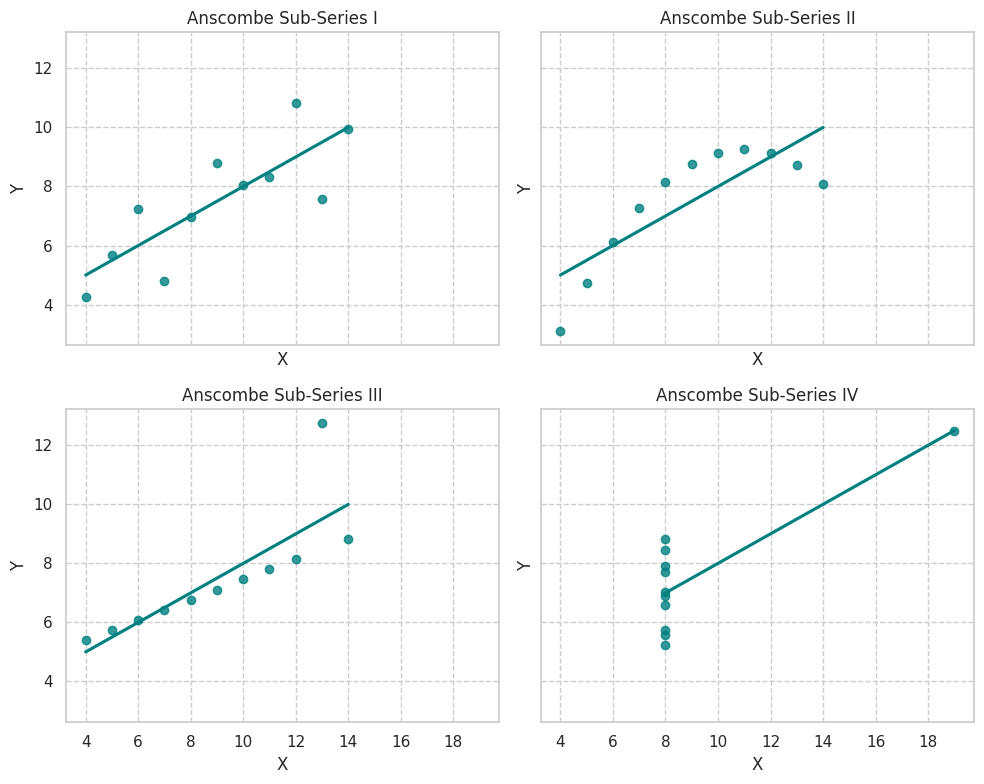

In [73]:
#Naming series and converting the grid matrix into a flat 1D array for loops
series_names = ['I', 'II', 'III', 'IV']
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten() # Convert the grid matrix into a flat 1D array for loops

# Using the 1D array in a loop, sepparating each series
for idx, name in enumerate(series_names):
    subset = df_anscombe[df_anscombe['Series'] == name] #calling each category of the column 'series'
    sns.regplot(data=subset, x='X', y='Y', ax=axes[idx], color='teal', ci=None)
    axes[idx].set_title(f'Anscombe Sub-Series {name}')
    axes[idx].grid(True, linestyle='--')

# Visualizing the multi-panel 2x2 grid
plt.tight_layout()
plt.savefig('exercise_4_anscombe_quartet.png', bbox_inches='tight')

## 5. Basic Histogram (Data Distribution Profiling)

Evaluate how real estate age structures are distributed inside the California Housing data.

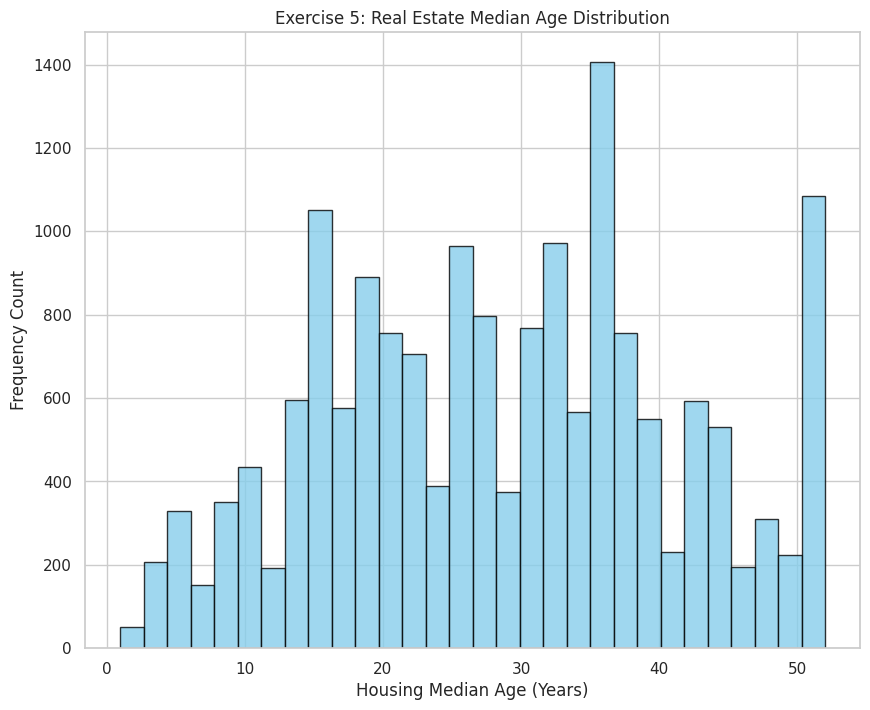

In [85]:
# Calling the df_housing data
df_housing = pd.read_csv("/content/sample_data/california_housing_train.csv")

# Defining the histogram axes and colors
fig, ax = plt.subplots(figsize=(10, 8))
ax.hist(df_housing['housing_median_age'], bins=30,
        color='skyblue', edgecolor='black', alpha=0.8)

# Visualizing the histogram of median age distribution
ax.set_title('Exercise 5: Real Estate Median Age Distribution')
ax.set_xlabel('Housing Median Age (Years)')
ax.set_ylabel('Frequency Count')
plt.savefig('exercise_5_histogram.png', bbox_inches='tight')

## 6. Kernel Density Estimate (KDE) Plots

Create a smooth probability density function curve for continuous numerical attributes.

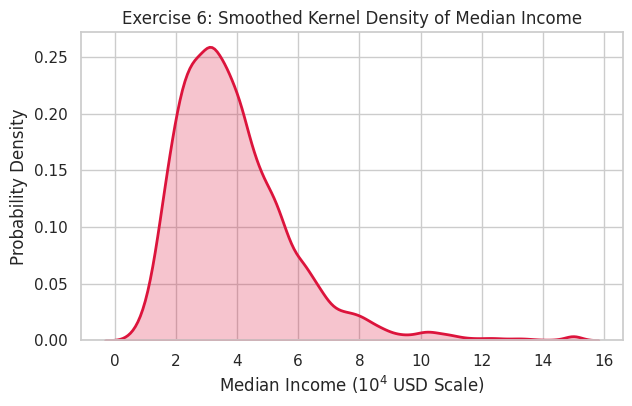

In [86]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df_housing, x='median_income', ax=ax, fill=True,
            color='crimson', linewidth=2)

ax.set_title('Exercise 6: Smoothed Kernel Density of Median Income')
ax.set_xlabel('Median Income ($10^4$ USD Scale)')
ax.set_ylabel('Probability Density')
plt.savefig('exercise_6_kde.png', bbox_inches='tight')

## 7. Layering Graphics (Histogram + KDE Combined)

Blend counts and absolute density estimations into a unified graph.

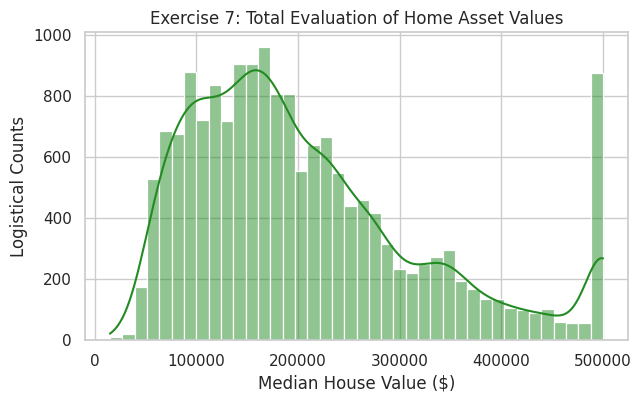

In [87]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df_housing, x='median_house_value',
             kde=True, ax=ax, color='forestgreen', bins=40)

ax.set_title('Exercise 7: Total Evaluation of Home Asset Values')
ax.set_xlabel('Median House Value ($)')
ax.set_ylabel('Logistical Counts')
plt.savefig('exercise_7_combined.png', bbox_inches='tight')

## 8. Categorical Count Plot (Sorted Bar Chart)

Group raw numbers into explicit categories and display them sorted by frequency count to prevent cluttered

/tmp/ipykernel_3110/2782293101.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_housing, x='Age_Tier', order=sorted_order, palette='viridis', ax=ax)


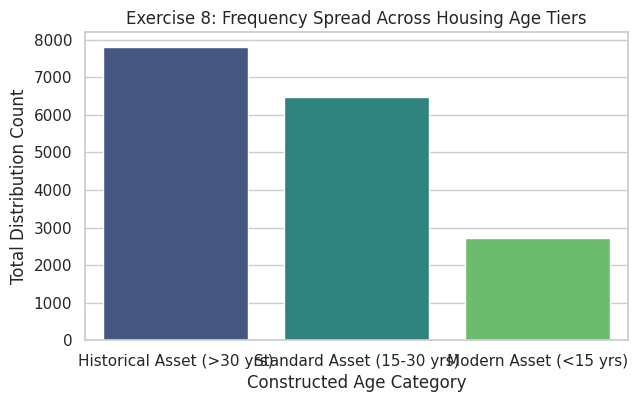

In [88]:
# Transform numerical ranges into customized descriptive category categories
def categorical_age(age):
    if age <= 15: return 'Modern Asset (<15 yrs)'
    elif age <= 30: return 'Standard Asset (15-30 yrs)'
    else: return 'Historical Asset (>30 yrs)'

df_housing['Age_Tier'] = df_housing['housing_median_age'].apply(categorical_age)
sorted_order = df_housing['Age_Tier'].value_counts().index # Order descending

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df_housing, x='Age_Tier', order=sorted_order,
              palette='viridis', ax=ax)

ax.set_title('Exercise 8: Frequency Spread Across Housing Age Tiers')
ax.set_xlabel('Constructed Age Category')
ax.set_ylabel('Total Distribution Count')
plt.savefig('exercise_8_countplot.png', bbox_inches='tight')

We found that the x-axis is illegible. For this reason, we rotate 90 degrees around this axe as we see next.

/tmp/ipykernel_3110/536103191.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_housing, x='Age_Tier', order=sorted_order, palette='viridis', ax=ax)
/tmp/ipykernel_3110/536103191.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right') # Rotate x-axis labels


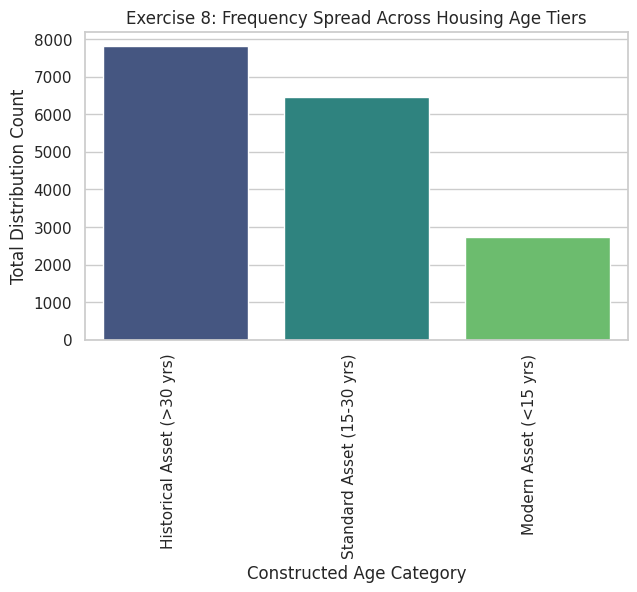

In [90]:
def categorical_age(age):
    if age <= 15: return 'Modern Asset (<15 yrs)'
    elif age <= 30: return 'Standard Asset (15-30 yrs)'
    else: return 'Historical Asset (>30 yrs)'

df_housing['Age_Tier'] = df_housing['housing_median_age'].apply(categorical_age)
sorted_order = df_housing['Age_Tier'].value_counts().index # Order descending

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df_housing, x='Age_Tier', order=sorted_order,
              palette='viridis', ax=ax)

ax.set_title('Exercise 8: Frequency Spread Across Housing Age Tiers')
ax.set_xlabel('Constructed Age Category')
ax.set_ylabel('Total Distribution Count')
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=90, ha='right') # Rotate x-axis labels
plt.savefig('exercise_8_countplot.png', bbox_inches='tight')

## 9. Horizontal Bar Chart (Sorted Aggregations)

Other way to visualize the same data is calculating aggregated group means and present them sorted horizontally for maximum visibility.

/tmp/ipykernel_3110/2498496238.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_prices.values, y=mean_prices.index, ax=ax, palette='mako', orient='h')


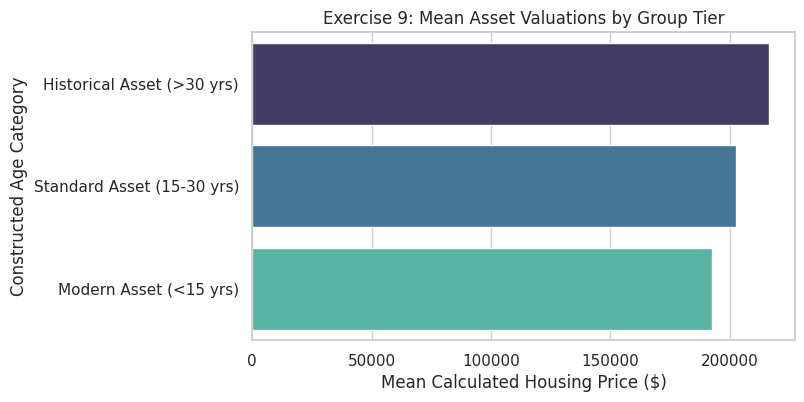

In [93]:
# Group by the engineered category and compute target mean values
mean_prices = df_housing.groupby('Age_Tier')['median_house_value'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=mean_prices.values, y=mean_prices.index, ax=ax, palette='mako', orient='h')

ax.set_title('Exercise 9: Mean Asset Valuations by Group Tier')
ax.set_xlabel('Mean Calculated Housing Price ($)')
ax.set_ylabel('Constructed Age Category')
plt.savefig('exercise_9_horizontal_bar.png', bbox_inches='tight')

## 10. Box Plots for Statistical Dispersion Analysis

Diagnose structural statistical parameters (median, quartiles) and identify outliers.

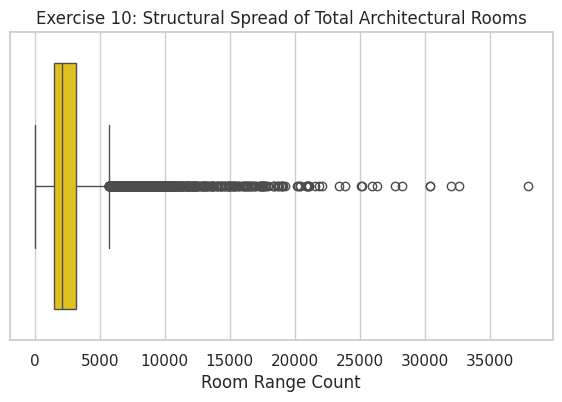

In [94]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_housing, x='total_rooms', ax=ax, color='gold')

ax.set_title('Exercise 10: Structural Spread of Total Architectural Rooms')
ax.set_xlabel('Room Range Count')
plt.savefig('exercise_10_boxplot.png', bbox_inches='tight')

## 11. Violin Plots for Complex Density Distributions

Combine box plot features with symmetrical kernel density elements for categorical data.

/tmp/ipykernel_3110/2832075112.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_housing, x='Age_Tier', y='median_income', ax=ax, palette='pastel')


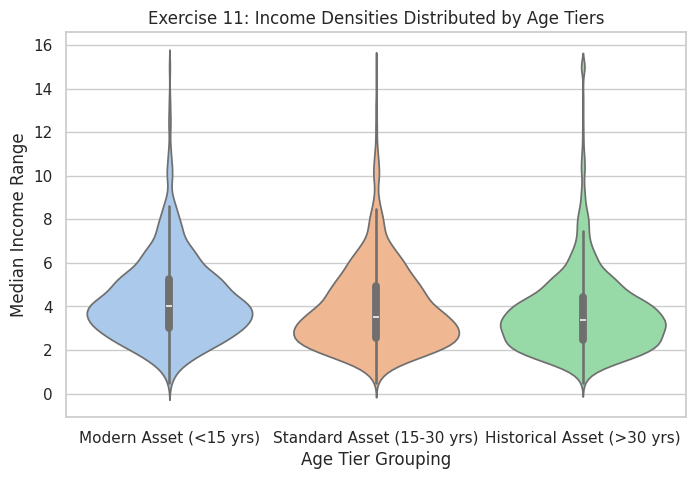

In [95]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df_housing, x='Age_Tier', y='median_income',
               ax=ax, palette='pastel')

ax.set_title('Exercise 11: Income Densities Distributed by Age Tiers')
ax.set_xlabel('Age Tier Grouping')
ax.set_ylabel('Median Income Range')
plt.savefig('exercise_11_violinplot.png', bbox_inches='tight')

## 12: Basic Geographic Mapping (Coordinate Points Scatter)

Recreate map matrices using spatial coordinate markers directly extracted from California columns.

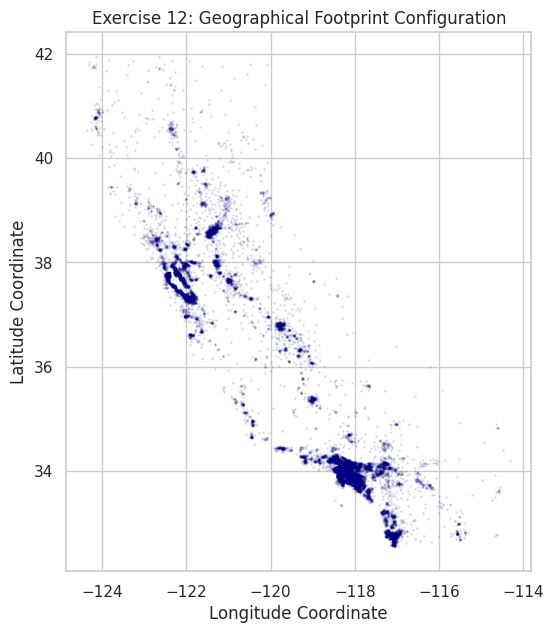

In [97]:
fig, ax = plt.subplots(figsize=(6, 7))
# Use very small transparency thresholds to clearly identify densely, settled points
ax.scatter(df_housing['longitude'], df_housing['latitude'], alpha=0.1,
           color='navy', s=0.8)

ax.set_title('Exercise 12: Geographical Footprint Configuration')
ax.set_xlabel('Longitude Coordinate')
ax.set_ylabel('Latitude Coordinate')
plt.savefig('exercise_12_geo_basic.png', bbox_inches='tight')

## 13. High-Dimensional Geographic Bubble Map

Objective: Link spatial dimensions to numerical value layers, configuring color palettes to map prices and dot sizes to represent population density.

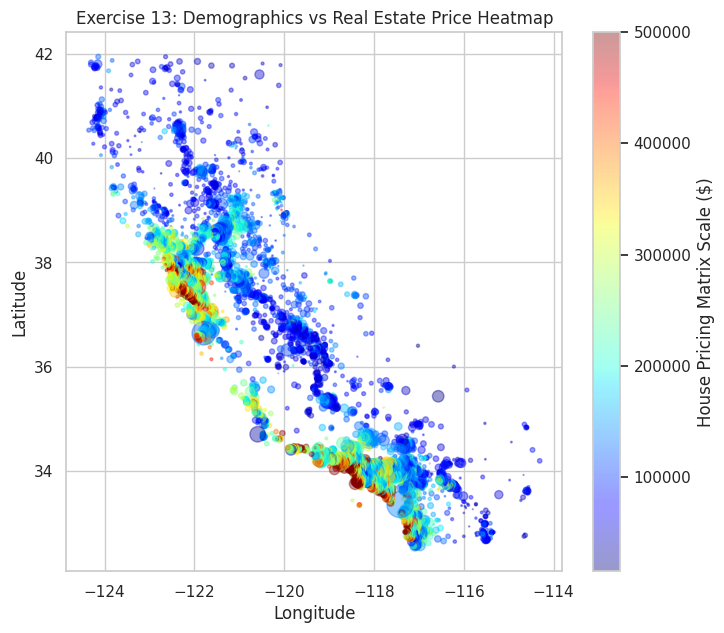

In [99]:
fig, ax = plt.subplots(figsize=(8, 7))
spatial_map = ax.scatter(df_housing['longitude'], df_housing['latitude'],
                         alpha=0.4,
                         c=df_housing['median_house_value'], cmap='jet',
                         s=df_housing['population']/100,
                          label='Population Matrix scale')

ax.set_title('Exercise 13: Demographics vs Real Estate Price Heatmap')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
colorbar_legend = fig.colorbar(spatial_map, ax=ax)
colorbar_legend.set_label('House Pricing Matrix Scale ($)')
plt.savefig('exercise_13_geo_advanced.png', bbox_inches='tight')

## 14. Visualizing Correlation Matrices (Heatmaps)

Quantify and display multi-variable statistical connections ($r$ coefficients).

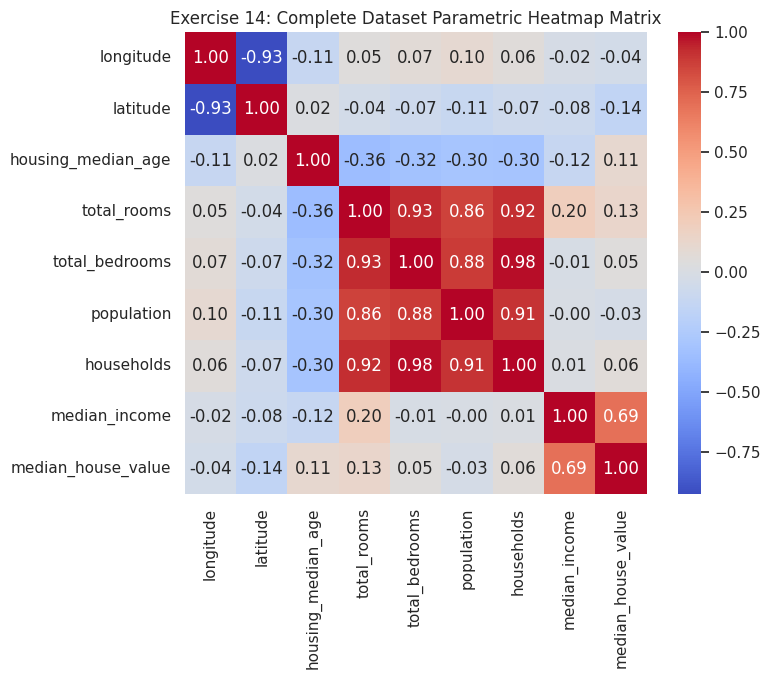

In [104]:
numerical_correlations = df_housing.drop(columns=['Age_Tier']).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(numerical_correlations, annot=True, fmt=".2f", cmap='coolwarm',
            ax=ax, square=True)

ax.set_title('Exercise 14: Complete Dataset Parametric Heatmap Matrix')
plt.savefig('exercise_14_heatmap.png', bbox_inches='tight')

## 15. Exploratory Relationship Matrices (Pair Plots)

Generate a complete multi-column visualization grid mapping pairwise metrics.

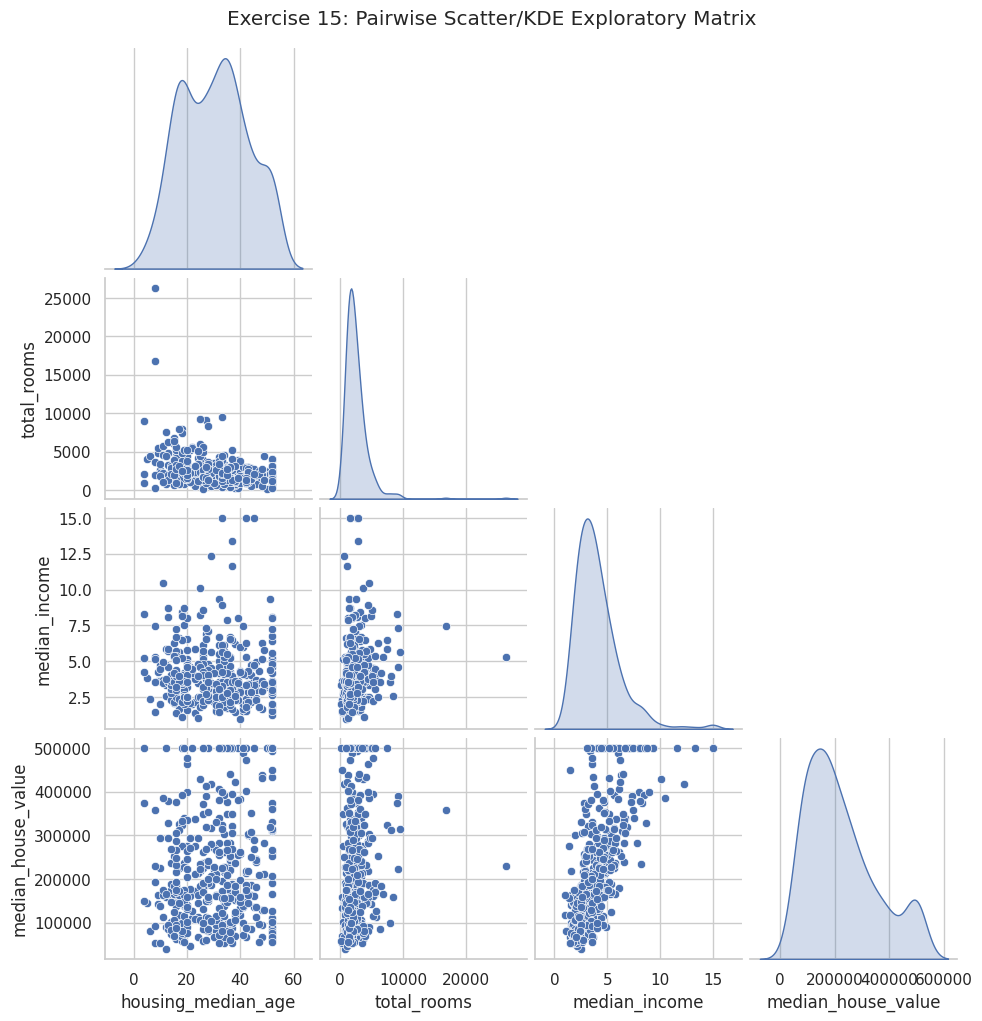

In [105]:
target_features = ['housing_median_age', 'total_rooms', 'median_income', 'median_house_value']

# Sample the dataset to optimize processing speeds
sampled_df = df_housing[target_features].sample(400, random_state=42)
pair_grid = sns.pairplot(sampled_df, diag_kind='kde', corner=True)
pair_grid.fig.suptitle('Exercise 15: Pairwise Scatter/KDE Exploratory Matrix', y=1.02)
pair_grid.savefig('exercise_15_pairplot.png', bbox_inches='tight')

## 16. Joint Plots with Multi-Axis Margins

Display shared distributions and separate individual univariate distributions on a unified grid.

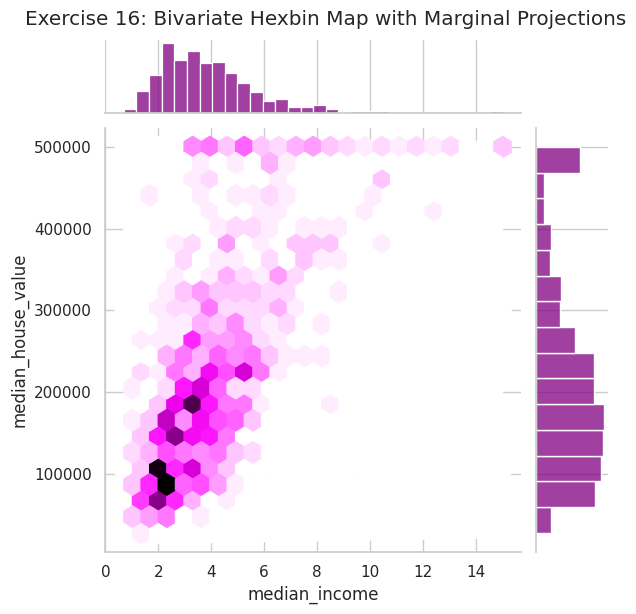

In [107]:
sampled_joint = df_housing.sample(800, random_state=42)
joint_chart = sns.jointplot(data=sampled_joint, x='median_income',
                            y='median_house_value', kind='hex', color='purple')

joint_chart.fig.suptitle('Exercise 16: Bivariate Hexbin Map with Marginal Projections', y=1.02)
joint_chart.savefig('exercise_16_jointplot.png', bbox_inches='tight')

## 17. Rendering Image Matrices from Pixels (MNIST)

Extract tabular row items, map them to matrix shapes, and display them as visual objects using pixel configurations.

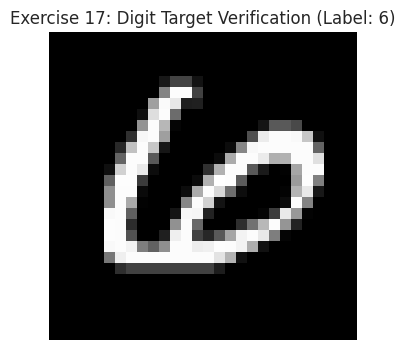

In [108]:
# Load image data without structural index tables
df_mnist = pd.read_csv("/content/sample_data/mnist_train_small.csv", header=None)

matrix_label = df_mnist.iloc[0, 0]
# Reshape the 784 structural features back to a 28 x 28 array
image_pixels = df_mnist.iloc[0, 1:].values.reshape(28, 28)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(image_pixels, cmap='gray')

ax.set_title(f'Exercise 17: Digit Target Verification (Label: {matrix_label})')
ax.axis('off') # Deactivate pixel indexes for a cleaner look
plt.savefig('exercise_17_mnist_single.png', bbox_inches='tight')

## 18. Multi-Row/Multi-Column Image Layout Subplots

Arrange pixel matrix distributions into organized row and column configurations.

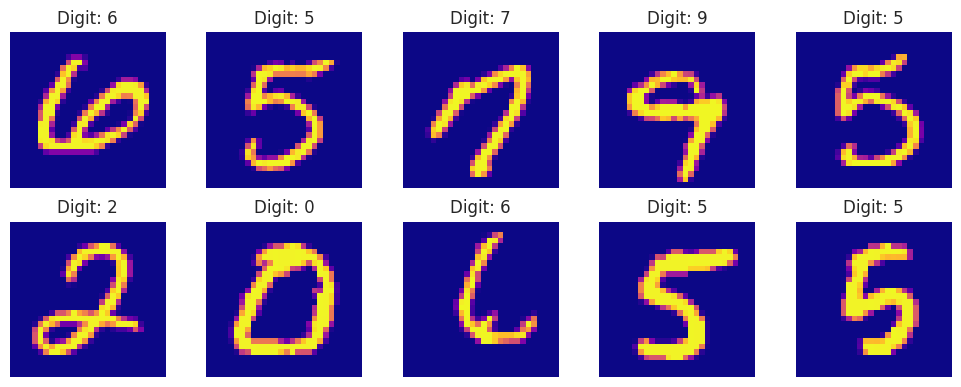

In [109]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for current_idx in range(10):
    digit_label = df_mnist.iloc[current_idx, 0]
    digit_pixels = df_mnist.iloc[current_idx, 1:].values.reshape(28, 28)

    axes[current_idx].imshow(digit_pixels, cmap='plasma')
    axes[current_idx].set_title(f'Digit: {digit_label}')
    axes[current_idx].axis('off')

plt.tight_layout()
plt.savefig('exercise_18_mnist_grid.png', bbox_inches='tight')

## 19. Sorted Target Distribution Verification (Class Balance)

Build sorted evaluation bars to check for classification target balance.

/tmp/ipykernel_3110/978463871.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mnist_frequencies.index, y=mnist_frequencies.values, order=mnist_frequencies.index, palette='rocket', ax=ax)


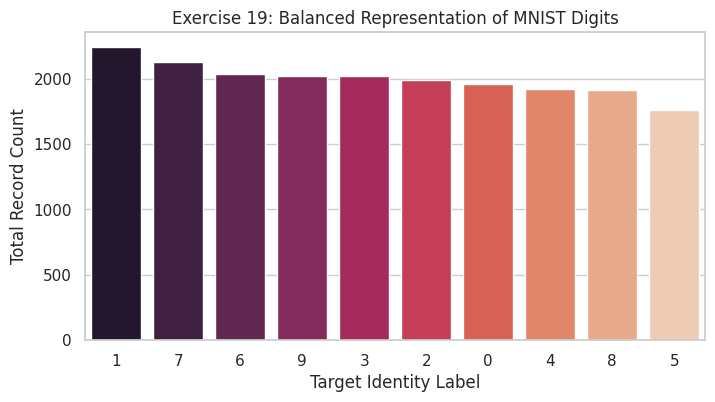

In [110]:
mnist_frequencies = df_mnist[0].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=mnist_frequencies.index, y=mnist_frequencies.values, order=mnist_frequencies.index, palette='rocket', ax=ax)

ax.set_title('Exercise 19: Balanced Representation of MNIST Digits')
ax.set_xlabel('Target Identity Label')
ax.set_ylabel('Total Record Count')
plt.savefig('exercise_19_mnist_distribution.png', bbox_inches='tight')

## 20. Advanced Dual-Axis Charting

Map metrics with fundamentally different mathematical scales on a shared independent variable axis.

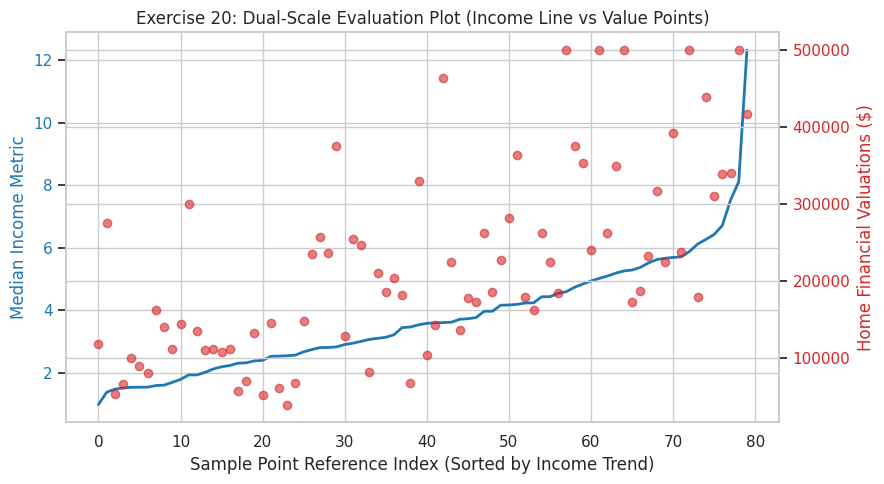

In [111]:
# Sample and order data items systematically along the scale parameter
ordered_sample = df_housing.sample(80, random_state=42).sort_values(by='median_income')

fig, primary_axis = plt.subplots(figsize=(9, 5))

blue_color = 'tab:blue'
primary_axis.set_xlabel('Sample Point Reference Index (Sorted by Income Trend)')
primary_axis.set_ylabel('Median Income Metric', color=blue_color)
primary_axis.plot(range(80), ordered_sample['median_income'], color=blue_color, linewidth=2)
primary_axis.tick_params(axis='y', labelcolor=blue_color)

# Generate a secondary axis that mirrors the existing independent x-axis container
secondary_axis = primary_axis.twinx()
red_color = 'tab:red'
secondary_axis.set_ylabel('Home Financial Valuations ($)', color=red_color)
secondary_axis.scatter(range(80), ordered_sample['median_house_value'], color=red_color, alpha=0.6)
secondary_axis.tick_params(axis='y', labelcolor=red_color)

primary_axis.set_title('Exercise 20: Dual-Scale Evaluation Plot (Income Line vs Value Points)')
fig.tight_layout()
plt.savefig('exercise_20_dual_axis.png', bbox_inches='tight')